# Nutritional Products Sales Breakdown

## Table of Contents <a id='back'></a>
- [Project Introduction](#project-introduction)
    - [Analysis Outline](#analysis-outline)
    - [Executive Summary](#executive-summary)
- [Importing Libraries and Opening Data Files](#importing-libraries-and-opening-data-files)
- [Data Wrangling](#data-wrangling)
    - [Duplicates](#duplicates)
    - [Missing Values](#missing-values)
    - [Data Transformation](#data-transformation)
    - [Removing Irrelevant Data](#removing-irrelevant-data)
- [Exploratory Data Analysis](#exploratory-data-analysis)
- [Conclusions and Reccomendations](#conclusions-and-reccomendations)
- [Dataset Citation](#dataset-citation)

## Project Introduction

[project intro]

### Analysis Outline

[Analysis Outline]

### Executive Summary

[Results]


[Back to Table of Contents](#back)

## Importing Libraries and Opening Data Files

In [ ]:
# Importing the needed libraries for this assignment
import pandas as pd
import mysql.connector
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
# Importing data from MySQL
try:
    conn = mysql.connector.connect(
        user='root',
        password='password', # local password
        host='localhost',
        database='supplement_sales',
        port=3306)

except:
    conn = mysql.connector.connect(
        user='root',
        password='password', # local password
        host='localhost',
        database='supplement_sales',
        port=3306)

In [3]:
# Using pandas to save the data from MySQL to a Python DataFrame for later data manipulation
df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


C:\Users\jason\AppData\Local\Temp\ipykernel_18944\418239610.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM supp_weekly_sales_cleaned', conn)


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


[Back to Table of Contents](#back)

## Data Wrangling

### Duplicates

In [4]:
# Checking for duplicates
df.duplicated().sum()

0

[Back to Table of Contents](#back)

### Missing Values

In [5]:
# Checking for null values
df.isna().sum()

week_date         0
product_name      0
category          0
units_sold        0
price             0
total_revenue     0
discount          0
units_returned    0
location          0
platform          0
dtype: int64

[Back to Table of Contents](#back)

### Data Transformation

In [6]:
# Getting general information about the dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   week_date       4384 non-null   object 
 1   product_name    4384 non-null   object 
 2   category        4384 non-null   object 
 3   units_sold      4384 non-null   int64  
 4   price           4384 non-null   int64  
 5   total_revenue   4384 non-null   int64  
 6   discount        4384 non-null   float64
 7   units_returned  4384 non-null   int64  
 8   location        4384 non-null   object 
 9   platform        4384 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 342.6+ KB


,week_date,product_name,category,units_sold,price,total_revenue,discount,units_returned,location,platform
0,2020-01-06,whey_protein,protein,143,32,4573,0.03,2,canada,walmart
1,2020-01-06,vitamin_c,vitamin,139,43,5909,0.04,0,uk,amazon
2,2020-01-06,fish_oil,omega,161,13,2079,0.25,0,canada,amazon
3,2020-02-24,ashwagandha,herbal,133,27,3612,0.18,2,uk,iherb
4,2020-01-06,multivitamin,vitamin,140,16,2250,0.08,0,canada,walmart


In [7]:
#checking for snakecase format
df.columns

Index(['week_date', 'product_name', 'category', 'units_sold', 'price',
       'total_revenue', 'discount', 'units_returned', 'location', 'platform'],
      dtype='object')

Observation:

- The data appears to be well processed. The column names and values are formatted in snake_case, indicating that the transformations applied in SQL were successfully carried over into Python.

In [ ]:
# Converting week_date column into datetime data type for later extraction and manipulation
df['week_date'] = pd.to_datetime(df['week_date'], format='%Y-%m-%d')

# Extracting week, month, quarter, and year values from week_date column for improved time based analysis
df['week'] = df['week_date'].dt.isocalendar().week
df['month'] = df['week_date'].dt.month
df['quarter'] = df['week_date'].dt.quarter
df['year'] = df['week_date'].dt.year

In [9]:
# Looking at the value ranges for the numeric columns and see if there are any outliers or entry errors
print(f'Max units sold: {df['units_sold'].max()}')
print(f'Min units sold: {df['units_sold'].min()}')
print(f'Max price: {df['price'].max()}')
print(f'Min price: {df['price'].min()}')
print(f'Max total revenue: {df['total_revenue'].max()}')
print(f'Min total revenue: {df['total_revenue'].min()}')
print(f'Max units returned: {df['units_returned'].max()}')
print(f'Min units returned: {df['units_returned'].min()}')

Max units sold: 194
Min units sold: 103
Max price: 60
Min price: 10
Max total revenue: 10762
Min total revenue: 1284
Max units returned: 8
Min units returned: 0


Observation:

- Based on the value ranges of the numeric columns, all data falls within reasonable limits. There are no obvious extreme outliers or negative values that would skew the results or require removal.

In [ ]:
# Saving the new cleaned dataset if needed
df.to_csv('cleaned_supplement_sales_data.csv', index=False)

[Back to Table of Contents](#back)

## Exploratory Data Analysis

### Time-Based Exploration

#### Geographic Monthly Trends

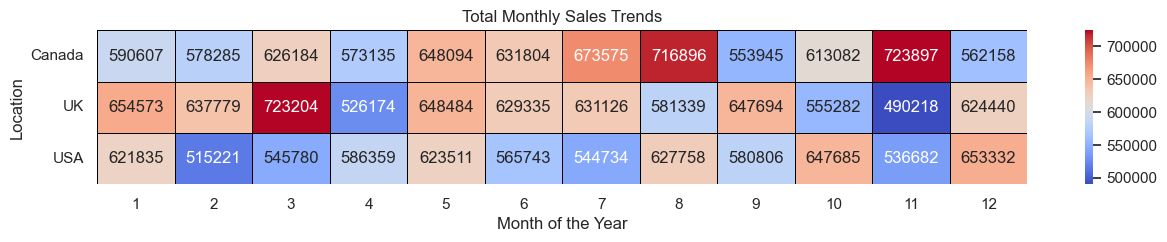

In [ ]:
# Setting theme and figure size for graphs
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15, 2))

# Filtering for full years only so aggregate monthly data does not skew
df_full = df[df['year'] < 2025] 

# Creating and plotting a pivot table of monthly sales per year
monthly_trends = df_full.pivot_table(index='location',
                                     columns='month',
                                     values='total_revenue',
                                     aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(monthly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Total Monthly Sales Trends')
ax.set_xlabel('Month of the Year')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- 

[Back to Table of Contents](#back)

#### Annual Trends

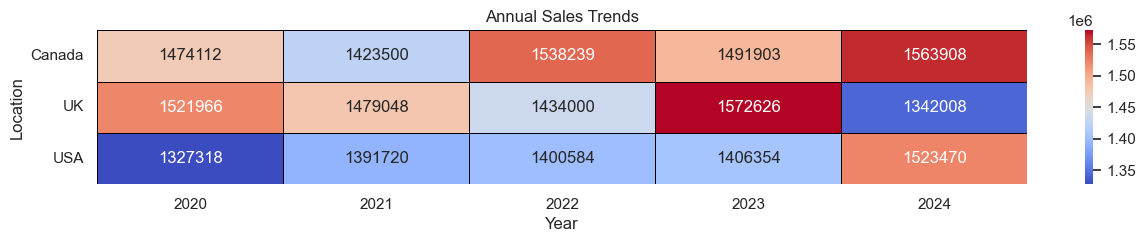

In [41]:
# Setting figure size for graphs
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of monthly sales per year
yearly_trends = df_full.pivot_table(index='location',
                                    columns='year',
                                    values='total_revenue',
                                    aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(yearly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Annual Sales Trends')
ax.set_xlabel('Year')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- 

[Back to Table of Contents](#back)

#### Quarterly Trends

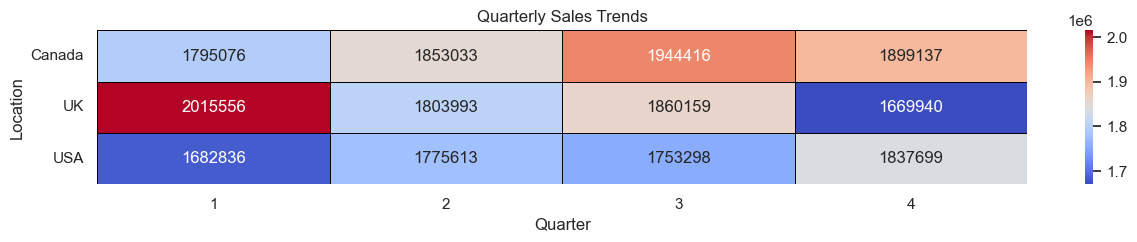

In [45]:
# Setting figure size for graphs
plt.figure(figsize=(15, 2))

# Creating and plotting a pivot table of monthly sales per year
quarterly_trends = df_full.pivot_table(index='location',
                                       columns='quarter',
                                       values='total_revenue',
                                       aggfunc='sum')
# Creating a heatmap for the pivot table data
ax = sns.heatmap(quarterly_trends,
                 cmap='coolwarm',
                 annot=True,
                 fmt='.0f',
                 linewidths=.5,
                 linecolor='black')
ax.set_title('Quarterly Sales Trends')
ax.set_xlabel('Quarter')
ax.set_ylabel('Location')
ax.set_yticklabels(['Canada', 'UK', 'USA'], rotation=360)
plt.show()

Observation:

- 

[Back to Table of Contents](#back)

### Product Performance

#### Best / Worst Product Categories by Platform

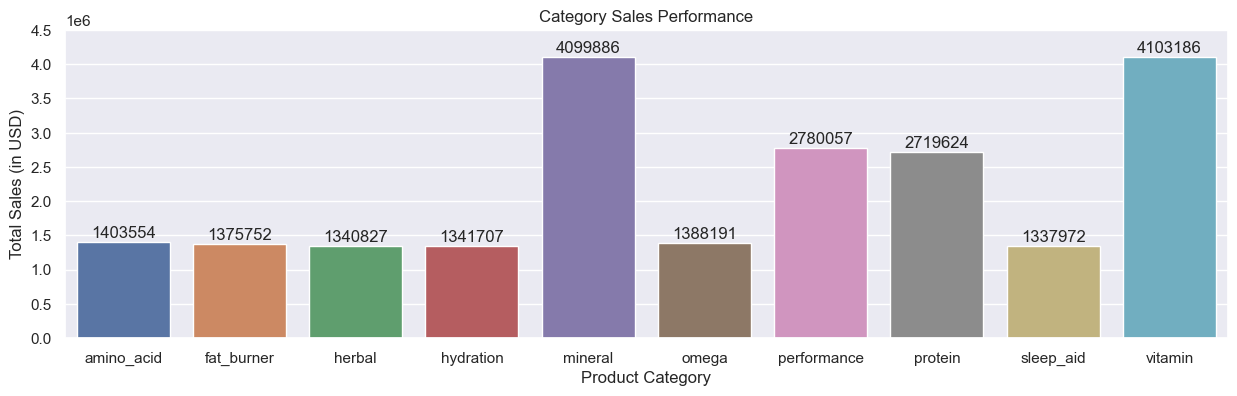

In [ ]:
# Setting figure size
plt.figure(figsize=(15, 4))

# Creating aggregate sales for each category
agg_sales = df_full.groupby('category')['total_revenue'].sum().reset_index()

# Bar graph for total sales by product category
ax = sns.barplot(data=agg_sales,
                  x='category',
                  y='total_revenue',
                  hue='category',
                  errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Category Sales Performance')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Sales (in USD)')
ax.set_ylim(0, 4500000)

plt.show()

Observation:

- 

[Back to Table of Contents](#back)

#### Most Returns

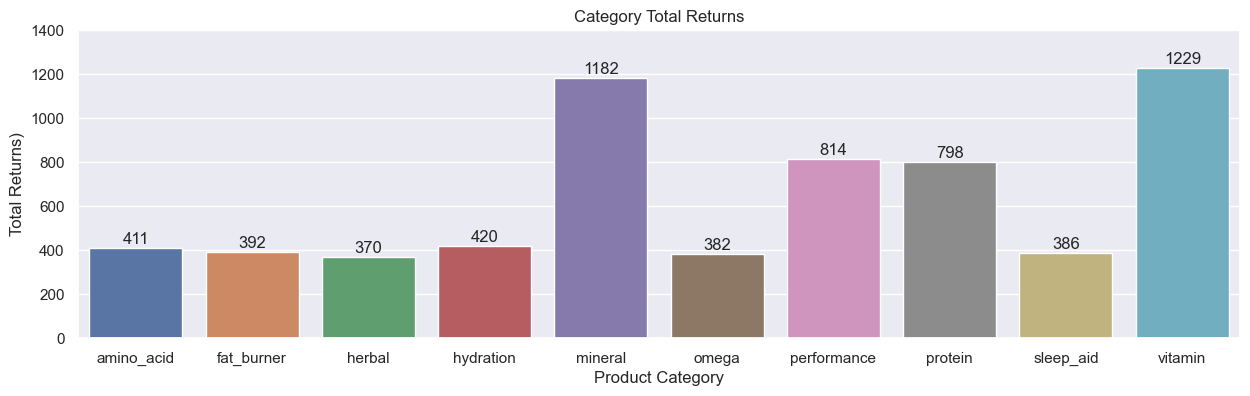

In [ ]:
# Setting figure size
plt.figure(figsize=(15, 4))

# Creating aggregate returns for each category
agg_returns = df_full.groupby('category')['units_returned'].sum().reset_index()

# Bar graph for total returns by category
ax = sns.barplot(data=agg_returns,
                  x='category',
                  y='units_returned',
                  hue='category',
                  errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Category Total Returns')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Returns')
ax.set_ylim(0, 1400)

plt.show()

Observation:

- 

[Back to Table of Contents](#back)

### Customer Demographic

#### Sales by Location

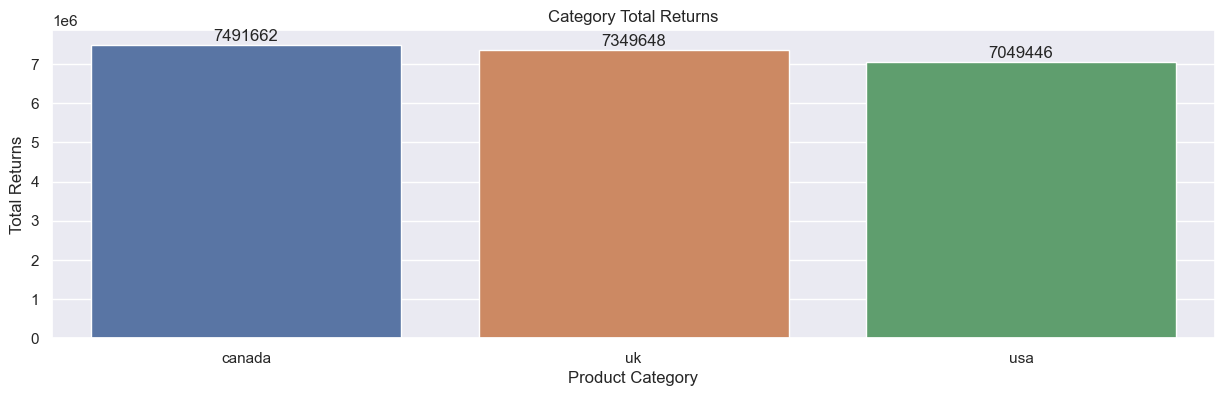

In [28]:
# Setting figure size
plt.figure(figsize=(15, 4))

# Creating aggregate returns for each location
agg_returns = df_full.groupby('location')['total_revenue'].sum().reset_index()

# Bar graph for total returns by location
ax = sns.barplot(data=agg_returns,
                  x='location',
                  y='total_revenue',
                  hue='location',
                  errorbar=None)
# Creating loop to display numeric value on graph
for r in ax.patches:
    y_value = r.get_height()
    x_value = r.get_x() + r.get_width() / 2
    label = '{:.0f}'.format(y_value)
    ax.annotate(label,
                (x_value, y_value),
                xytext=(0, 1),
                textcoords='offset points',
                ha='center',
                va='bottom')
ax.set_title('Category Total Returns')
ax.set_xlabel('Product Category')
ax.set_ylabel('Total Returns')
#ax.set_ylim(0, 1400)

plt.show()

Observation:

- 

[Back to Table of Contents](#back)

## Conclusions and Reccomendations



[Back to Table of Contents](#back)

## Dataset Citation

Zahid Feroze. (2025, November). Supplement Sales Data, Version 1. Retrieved November 3, 2025 from [Kaggle](https://www.kaggle.com/datasets/zahidmughal2343/supplement-sales-data)

[Back to Table of Contents](#back)